# Лабораторная работа 2
## Neural ODE для прогнозирования AirPassengers
Исследуем непрерывную динамику скрытого состояния, прогноз на 12 месяцев и
устойчивость к повреждению истории наблюдений. 

## Данные
Классический ряд Box–Jenkins AirPassengers: месячный международный
пассажиропоток в тысячах, январь 1949 — декабрь 1960, 144 наблюдения.
[Документация R](https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/AirPassengers.html),
[CSV](https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/AirPassengers.csv).
[Neural ODE, Chen et al., 2018](https://proceedings.neurips.cc/paper/2018/hash/69386f6bb1dfed68692a24c8686939b9-Abstract.html).


PyTorch: 2.14.0 | CPU | seed: 42
{
  "observations": 144,
  "missing": 0,
  "duplicate_rows": 0,
  "duplicate_times": 0,
  "min": 104.0,
  "max": 622.0,
  "mean": 280.2986145019531,
  "std": 119.54904174804688,
  "sha256": "bdb98adbd418a6de6842a742e0602f363c3b841c26677e7e61a1e055e9509bd8"
}
Подозрительные годовые изменения (не удаляем автоматически): []


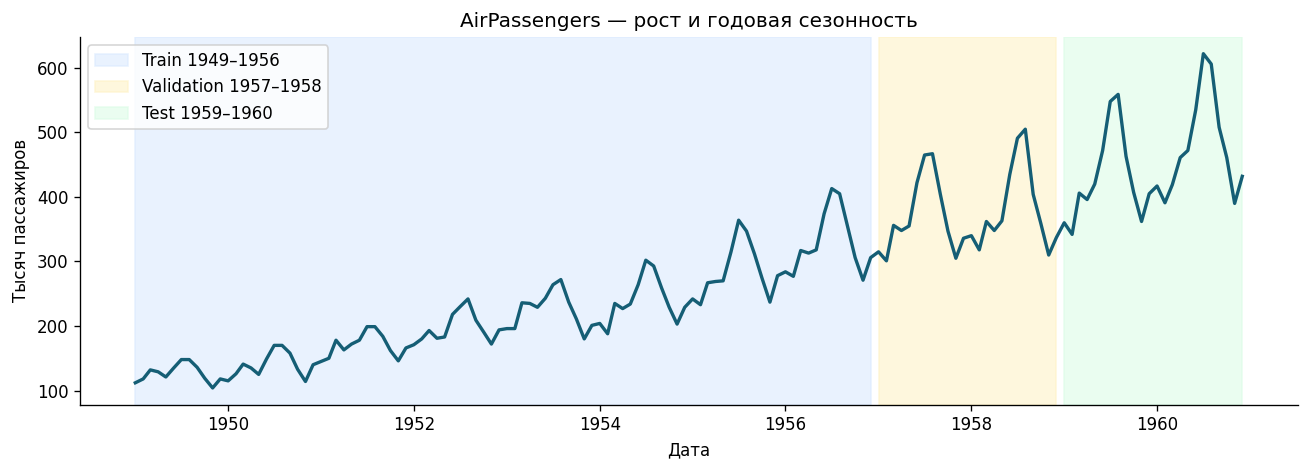

In [1]:
from pathlib import Path
import copy, hashlib, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from torch import nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
ROOT = Path.cwd()
FIG = ROOT / 'figures'
FIG.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.family': 'DejaVu Sans'})

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / f'{name}.png', dpi=170, bbox_inches='tight')
    plt.show()

SOURCE = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/AirPassengers.csv'
path = ROOT / 'data' / 'AirPassengers.csv'
if not path.exists():
    path.parent.mkdir(exist_ok=True)
    pd.read_csv(SOURCE).to_csv(path, index=False)
raw = pd.read_csv(path)
dates = pd.date_range('1949-01-01', periods=len(raw), freq='MS')
values = raw['value'].to_numpy(dtype=np.float32)
assert len(values) == 144 and np.isfinite(values).all() and (values > 0).all()
assert np.allclose(raw['time'], 1949 + np.arange(144)/12)
quality = {'observations': len(raw), 'missing': int(raw.isna().sum().sum()),
           'duplicate_rows': int(raw.duplicated().sum()),
           'duplicate_times': int(raw['time'].duplicated().sum()),
           'min': float(values.min()), 'max': float(values.max()),
           'mean': float(values.mean()), 'std': float(values.std()),
           'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
print('PyTorch:', torch.__version__, '| CPU | seed:', SEED)
print(json.dumps(quality, indent=2))

yoy = np.log(values[12:]) - np.log(values[:-12])
mad = np.median(np.abs(yoy - np.median(yoy)))
flags = np.abs(yoy - np.median(yoy)) > 4 * 1.4826 * mad
print('Подозрительные годовые изменения (не удаляем автоматически):', dates[12:][flags].strftime('%Y-%m').tolist())
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(dates, values, color='#155e75', lw=2)
for a,b,c,label in [(0,95,'#dbeafe','Train 1949–1956'),(96,119,'#fef3c7','Validation 1957–1958'),(120,143,'#dcfce7','Test 1959–1960')]:
    ax.axvspan(dates[a], dates[b], alpha=.6, color=c, label=label)
ax.set(title='AirPassengers — рост и годовая сезонность', ylabel='Тысяч пассажиров', xlabel='Дата')
ax.legend()
savefig('01_dataset')

## Постановка и защита от утечки будущего
Вход — последние 24 месяца $x\in\mathbb{R}^{24}$ и известная календарная фаза.
Цель — следующие 12 месяцев $y\in\mathbb{R}^{12}$. Прогноз строится целиком
из начального состояния: истинные будущие значения не подаются внутрь решателя.

Train: 1949–1956, validation: 1957–1958, test: 1959–1960. Окно включается
в часть, только если **все 12 целевых месяцев** принадлежат ей. История может
начинаться раньше границы. При сдвиге точки прогноза доступны уже наблюдённые
месяцы; это rolling-origin оценка, а не единственный прогноз на два года.
Перекрывающиеся окна зависимы: число окон не равно числу независимых экспериментов.

$z=(\log y-\mu_{train})/\sigma_{train}$; статистики оцениваются только на train.
Логарифм уменьшает различие амплитуд при росте уровня. Прогноз обратно
преобразуется экспонентой без поправки на смещение; MSE в log-шкале не
эквивалентна MSE в исходных единицах. Повторяющиеся значения пассажиропотока
не являются дубликатами объектов с разными датами. Календарь регулярный;
преимуществ на нерегулярных наблюдениях этот эксперимент не проверяет.

In [2]:
L, H = 24, 12
mu, sigma = float(np.log(values[:96]).mean()), float(np.log(values[:96]).std())
z = (np.log(values) - mu) / sigma

def windows(start, stop):
    origins = np.arange(max(L, start), stop-H+1)
    x = torch.tensor(np.stack([z[o-L:o] for o in origins]), dtype=torch.float32)
    y = torch.tensor(np.stack([z[o:o+H] for o in origins]), dtype=torch.float32)
    # Нулевая точка — последний наблюдённый месяц; t измеряется в годах.
    phase = torch.tensor((origins-1)%12/12, dtype=torch.float32)
    return x, y, phase, origins

parts = {'train': windows(0,96), 'validation': windows(96,120), 'test': windows(120,144)}
for name,(x,y,p,o) in parts.items():
    print(f'{name}: x={tuple(x.shape)}, y={tuple(y.shape)}, первые цели {dates[o[0]]:%Y-%m}, последние {dates[o[-1]+H-1]:%Y-%m}')
assert all((o[:,None]+np.arange(H) < end).all() and (o>=start).all()
           for (_,_,_,o),(start,end) in zip(parts.values(), [(24,96),(96,120),(120,144)]))

def inverse(a):
    if isinstance(a, torch.Tensor): a = a.detach().cpu().numpy()
    return np.exp(a*sigma+mu)

train: x=(61, 24), y=(61, 12), первые цели 1951-01, последние 1956-12
validation: x=(13, 24), y=(13, 12), первые цели 1957-01, последние 1958-12
test: x=(13, 24), y=(13, 12), первые цели 1959-01, последние 1960-12


## Математическая идея и схема
Сеть задаёт производную скрытого состояния, а не сразу 12 выходных значений:

$$h(0)=E_\phi(z_{o-24:o}-z_{o-1})\in\mathbb{R}^{12},\quad
\frac{dh(t)}{dt}=f_\theta(h(t),c(t)),\quad
c(t)=(\sin 2\pi(q+t),\cos 2\pi(q+t)).$$
$$\widehat z_{o+k-1}=z_{o-1}+w^\top[h(k/12)-h(0)],\quad k=1,\dots,12.$$

Схема: **24 наблюдения → log-нормализация → центрирование по последнему
наблюдению → encoder 24→32→12 → ODE 12→32→12 → линейное чтение в 12 моментах → exp**.
Последнее наблюдение служит опорным уровнем. Его вычитание помогает переносить
динамику на другой уровень ряда. Годовая периодичность явно внесена календарём,
а не целиком обнаружена сетью. Она известна до просмотра test.

Решатель RK4 с шагом $\Delta=1/12$ года:
$$k_1=f(t,h),\ k_2=f(t+\Delta/2,h+\Delta k_1/2),\
k_3=f(t+\Delta/2,h+\Delta k_2/2),\ k_4=f(t+\Delta,h+\Delta k_3),$$
$$h_{next}=h+\Delta(k_1+2k_2+2k_3+k_4)/6.$$
Обучение: $\mathcal L=\frac1{NH}\sum(\hat z-z)^2$, Adam, lr=0.003,
weight decay=0.0001, полный batch из train-окон, 500 эпох, clip grad norm=1.

**Индуктивная гипотеза:** единое гладкое векторное поле описывает изменение скрытых
признаков на всём горизонте. Время ODE соответствует будущему времени в годах;
$q$ — фаза последнего наблюдённого месяца. Координаты состояния обучаемые,
без заранее заданного физического смысла. Градиенты проходят через RK4 с помощью
обычного autograd; adjoint-метод не используется. Эпоха выбирается по validation MSE.

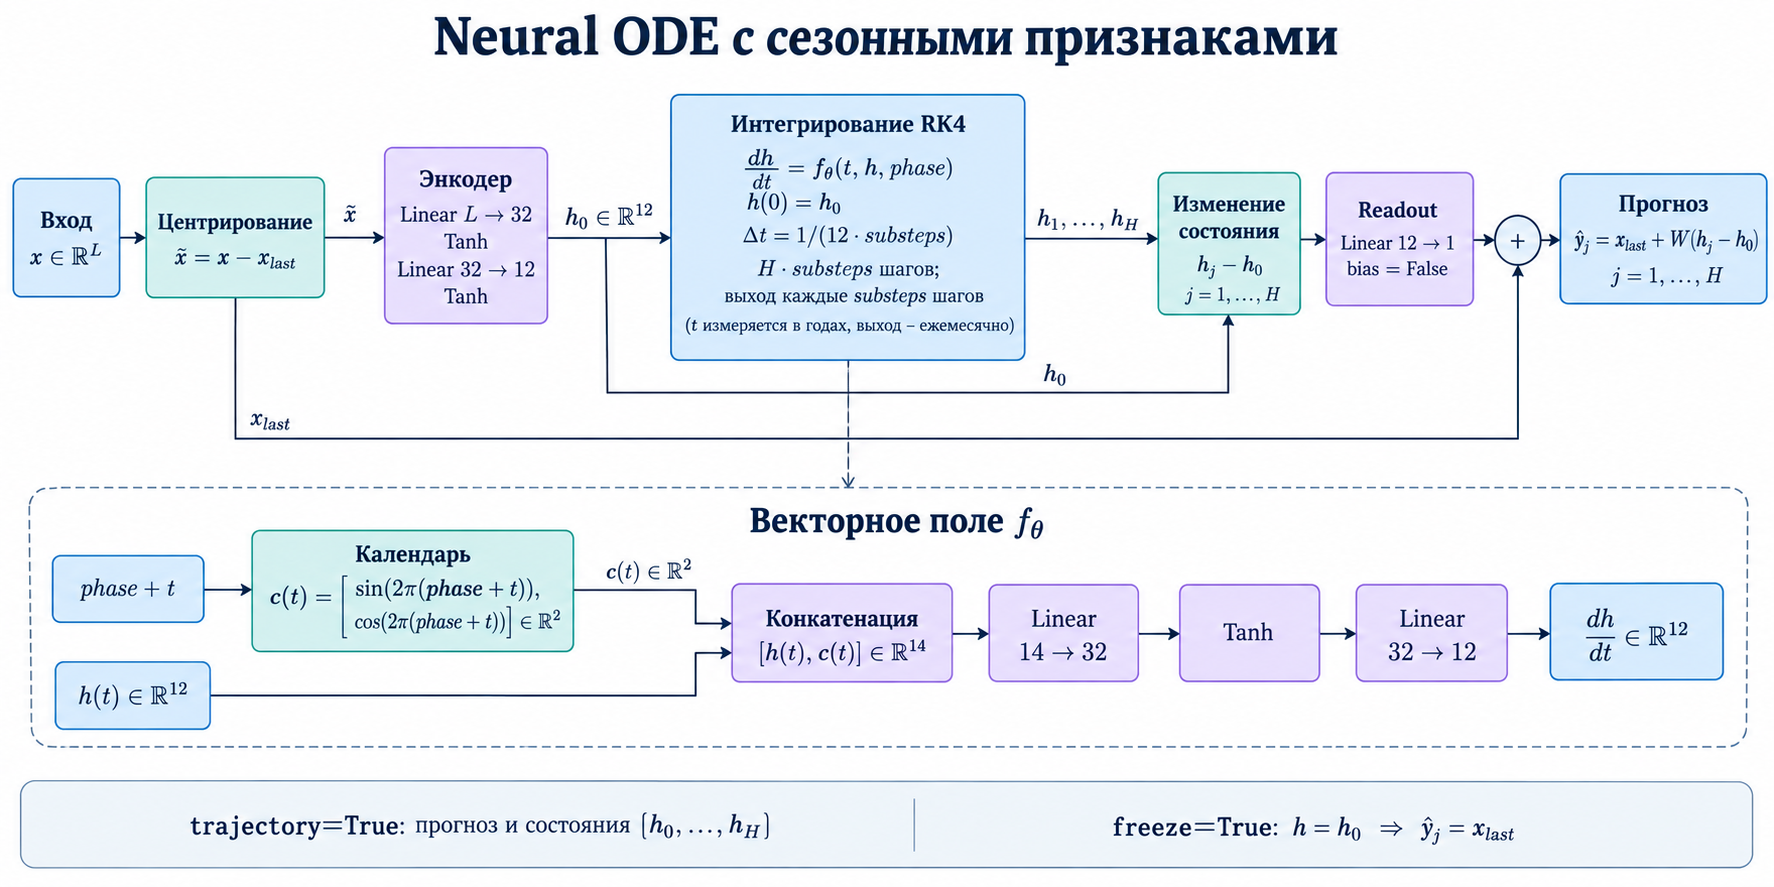

На схеме вход $x$ и выход сети обозначают нормализованные логарифмы. Для получения
тысяч пассажиров требуется обратное преобразование $\exp(\mu+\sigma\widehat z)$.


NeuralODE(
  (encoder): Sequential(
    (0): Linear(in_features=24, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=12, bias=True)
    (3): Tanh()
  )
  (field): Sequential(
    (0): Linear(in_features=14, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=12, bias=True)
  )
  (readout): Linear(in_features=12, out_features=1, bias=False)
)
Параметров: 2084
epoch 1: train MSE=0.32611; validation MSE=0.39139
epoch 100: train MSE=0.05658; validation MSE=0.11117
epoch 200: train MSE=0.04644; validation MSE=0.10723
epoch 300: train MSE=0.03740; validation MSE=0.10226
epoch 400: train MSE=0.02786; validation MSE=0.09716
epoch 500: train MSE=0.02148; validation MSE=0.09400
Лучшая эпоха: 436 | секунд: 7.1


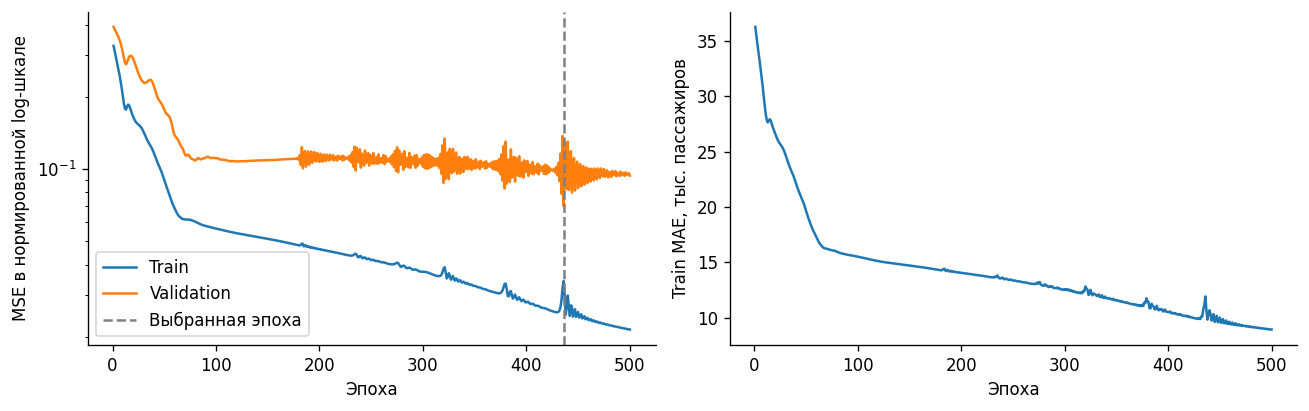

In [3]:
class NeuralODE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(L,32), nn.Tanh(), nn.Linear(32,12), nn.Tanh())
        self.field = nn.Sequential(nn.Linear(14,32), nn.Tanh(), nn.Linear(32,12))
        self.readout = nn.Linear(12,1,bias=False)

    def f(self, t, h, phase):
        angle = 2*torch.pi*(phase+t)
        calendar = torch.stack([angle.sin(),angle.cos()],dim=1)
        return self.field(torch.cat([h,calendar],dim=1))

    def forward(self,x,phase,substeps=1,trajectory=False,freeze=False):
        h0 = self.encoder(x-x[:,-1:])
        h = h0
        states, outputs = [h0], []
        dt = 1/(12*substeps)
        for k in range(H*substeps):
            t = k*dt
            if not freeze:
                a = self.f(t,h,phase)
                b = self.f(t+dt/2,h+dt*a/2,phase)
                c = self.f(t+dt/2,h+dt*b/2,phase)
                d = self.f(t+dt,h+dt*c,phase)
                h = h+dt*(a+2*b+2*c+d)/6
            if (k+1)%substeps == 0:
                states.append(h)
                outputs.append(x[:,-1]+self.readout(h-h0).squeeze(-1))
        prediction = torch.stack(outputs,dim=1)
        return (prediction,torch.stack(states,dim=1)) if trajectory else prediction

model = NeuralODE()
print(model)
print('Параметров:', sum(p.numel() for p in model.parameters()))
optimizer = torch.optim.Adam(model.parameters(),lr=.003,weight_decay=1e-4)
xt,yt,pt,_ = parts['train']
xv,yv,pv,_ = parts['validation']
history, best, best_state = [], float('inf'), None
started = time.time()
for epoch in range(1,501):
    model.train()
    optimizer.zero_grad()
    loss = (model(xt,pt)-yt).square().mean()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(),1.)
    optimizer.step()
    model.eval()
    with torch.no_grad():
        train_loss = (model(xt,pt)-yt).square().mean().item()
        val_loss = (model(xv,pv)-yv).square().mean().item()
    history.append({'epoch':epoch,'train_mse':train_loss,'validation_mse':val_loss,
                    'train_mae':float(np.abs(inverse(model(xt,pt).detach())-inverse(yt)).mean())})
    if val_loss < best:
        best, best_epoch = val_loss, epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch == 1 or epoch%100 == 0:
        print(f'epoch {epoch}: train MSE={train_loss:.5f}; validation MSE={val_loss:.5f}')
model.load_state_dict(best_state)
model.eval()
print('Лучшая эпоха:', best_epoch, '| секунд:', round(time.time()-started,1))
history = pd.DataFrame(history)
fig, axes = plt.subplots(1,2,figsize=(11,3.5))
axes[0].plot(history.epoch,history.train_mse,label='Train')
axes[0].plot(history.epoch,history.validation_mse,label='Validation')
axes[0].axvline(best_epoch,color='gray',ls='--',label='Выбранная эпоха')
axes[0].set(yscale='log',xlabel='Эпоха',ylabel='MSE в нормированной log-шкале')
axes[0].legend()
axes[1].plot(history.epoch,history.train_mae)
axes[1].set(xlabel='Эпоха',ylabel='Train MAE, тыс. пассажиров')
savefig('02_learning')

## Базовая оценка и контрольные прогнозы
### Метрики
1) MAE измеряются в тысячах пассажиров
2) RMSE измеряются в тысячах пассажиров 
3) MAPE — в процентах.

Метрики усредняются по всем парам «точка прогноза, горизонт»

Сравниваем Neural ODE с последним значением, сезонным повтором прошлого года
и сезонным повтором с ростом. Последний baseline умножает прошлый год на
отношение средних последних и предпоследних 12 месяцев истории.

     split                  model    MAE   RMSE  MAPE_pct
     train             Neural ODE 11.901 14.884     4.947
     train     Последнее значение 36.581 47.116    14.724
     train        Сезонный повтор 31.096 34.273    12.911
     train Сезонный повтор + рост 15.155 19.097     6.491
validation             Neural ODE 27.095 33.428     7.435
validation     Последнее значение 62.179 79.801    16.118
validation        Сезонный повтор 27.878 32.851     7.346
validation Сезонный повтор + рост 18.922 24.067     5.107
      test             Neural ODE 34.599 44.940     7.785
      test     Последнее значение 77.840 99.226    16.524
      test        Сезонный повтор 51.462 53.366    11.471
      test Сезонный повтор + рост 26.955 29.821     6.182
Типичное окно (медианная MAE): 1960-01-01 00:00:00 MAE 28.596949
Худшее окно: 1959-05-01 00:00:00 MAE 81.63281


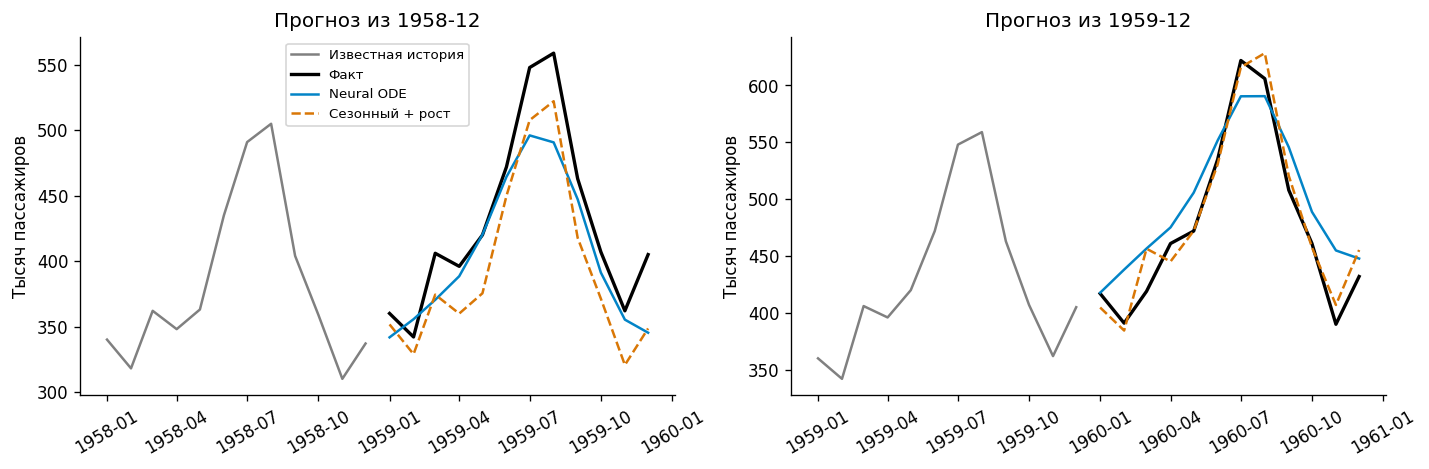

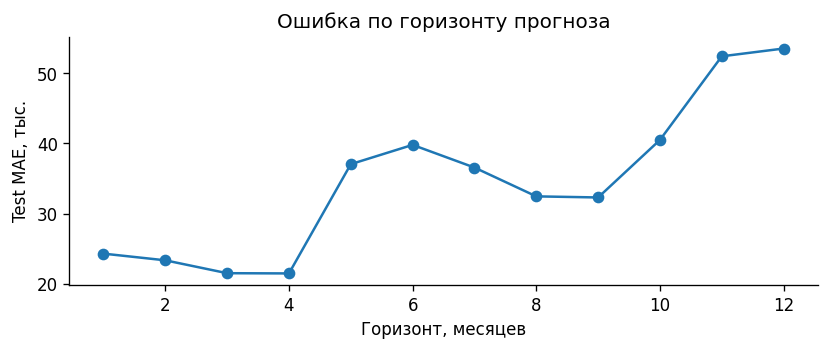

In [4]:
@torch.no_grad()
def predict(x,p,**kwargs):
    return inverse(model(x,p,**kwargs))

def metrics(y,p):
    e = p-y
    return {'MAE':float(np.abs(e).mean()),'RMSE':float(np.sqrt(np.mean(e**2))),
            'MAPE_pct':float(np.mean(np.abs(e)/y)*100)}

def baselines(x):
    a = inverse(x)
    seasonal = a[:,-12:]
    growth = a[:,-12:].mean(axis=1,keepdims=True)/a[:,:12].mean(axis=1,keepdims=True)
    return {'Последнее значение':np.repeat(a[:,-1:],H,axis=1),
            'Сезонный повтор':seasonal,'Сезонный повтор + рост':seasonal*growth}

rows=[]
for split,(x,y,p,o) in parts.items():
    for name,pred in {'Neural ODE':predict(x,p),**baselines(x)}.items():
        rows.append({'split':split,'model':name,**metrics(inverse(y),pred)})
score = pd.DataFrame(rows)
print(score.round(3).to_string(index=False))
x,y,phase,origins = parts['test']
truth, pred = inverse(y), predict(x,phase)
window_mae = np.abs(pred-truth).mean(axis=1)
good = int(np.argmin(np.abs(window_mae-np.median(window_mae))))
bad = int(np.argmax(window_mae))
print('Типичное окно (медианная MAE):', dates[origins[good]], 'MAE', window_mae[good])
print('Худшее окно:', dates[origins[bad]], 'MAE', window_mae[bad])
fig,axes=plt.subplots(1,2,figsize=(12,4))
# Две точки дают неперекрывающиеся прогнозы 1959 и 1960 годов.
for ax,i in zip(axes,[0,len(origins)-1]):
    o=origins[i]
    ax.plot(dates[o-12:o],values[o-12:o],color='gray',label='Известная история')
    ax.plot(dates[o:o+H],truth[i],color='black',lw=2,label='Факт')
    ax.plot(dates[o:o+H],pred[i],color='#0284c7',label='Neural ODE')
    ax.plot(dates[o:o+H],baselines(x)['Сезонный повтор + рост'][i],ls='--',color='#d97706',label='Сезонный + рост')
    ax.set(title=f'Прогноз из {dates[o-1]:%Y-%m}',ylabel='Тысяч пассажиров')
    ax.tick_params(axis='x',rotation=30)
axes[0].legend(fontsize=8)
savefig('03_forecasts')
fig,ax=plt.subplots(figsize=(7,3))
ax.plot(np.arange(1,13),np.abs(pred-truth).mean(axis=0),marker='o')
ax.set(xlabel='Горизонт, месяцев',ylabel='Test MAE, тыс.',title='Ошибка по горизонту прогноза')
savefig('04_horizon')

## Контролируемое нарушение входных данных
Меняем только историю test, сохраняя истинную цель: это повреждение измерений,
а не утверждение, что реальный пассажиропоток изменился без изменения будущего.
Сценарий 1 — случайный шум в log-шкале. Сценарий 2 — white-box FGSM:
$$x_{adv}=x+\epsilon\operatorname{sign}(\nabla_x\mathcal L(x,y)).$$
Истинная цель используется атакующим для стресс-теста; она не передаётся
модели как признак. $\epsilon$ указан в стандартизированной log-шкале.
В исходных единицах изменение ограничено множителями $\exp(\pm\sigma\epsilon)$.
Нет переобучения или выбора параметров по атакованному test.
Проверяем сетку 0, 0.05, 0.10, 0.20; для случайного шума — 10 повторов.
Искажения строятся отдельно для каждого окна: это отдельные запросы прогноза,
а не единая согласованная подмена всего ряда. У Gaussian ε — стандартное
отклонение, у FGSM — максимальная амплитуда; ограничения различаются.

          scenario  epsilon     MAE    RMSE  MAPE_pct  MAE_std
              FGSM     0.00  34.599  44.940     7.785      NaN
Gaussian mean (10)     0.00  34.599  44.940     7.785    0.000
              FGSM     0.05  59.432  73.371    13.375      NaN
Gaussian mean (10)     0.05  34.634  44.726     7.796    1.743
              FGSM     0.10  85.423 102.029    19.129      NaN
Gaussian mean (10)     0.10  36.121  46.472     8.111    3.190
              FGSM     0.20 128.929 151.117    28.715      NaN
Gaussian mean (10)     0.20  42.427  54.588     9.448    5.052
FGSM eps=0.1: множители измерений от 0.9672 до 1.0339


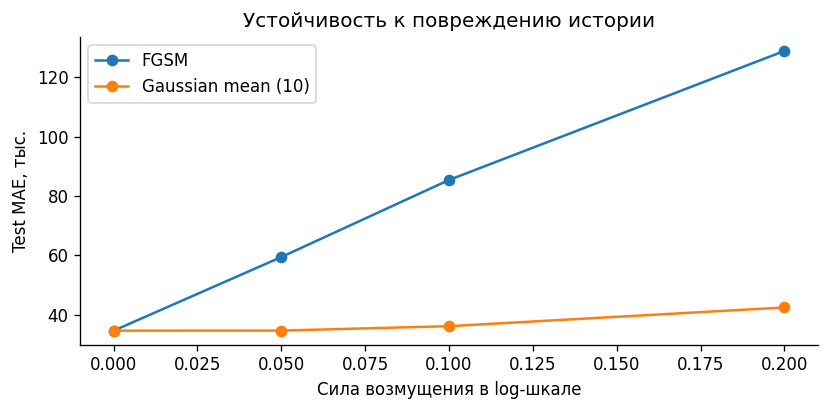

In [5]:
attack_x = x.clone().requires_grad_(True)
attack_loss=(model(attack_x,phase)-y).square().mean()
grad=torch.autograd.grad(attack_loss,attack_x)[0]
robust=[]
for eps in [0.,.05,.10,.20]:
    adv=x+eps*grad.sign()
    robust.append({'scenario':'FGSM','epsilon':eps,**metrics(truth,predict(adv,phase))})
    noise_scores=[]
    for seed in range(10):
        gen=torch.Generator().manual_seed(1000+seed)
        noisy=x+eps*torch.randn(x.shape,generator=gen)
        noise_scores.append(metrics(truth,predict(noisy,phase)))
    robust.append({'scenario':'Gaussian mean (10)','epsilon':eps,
                   **{k:float(np.mean([a[k] for a in noise_scores])) for k in noise_scores[0]},
                   'MAE_std':float(np.std([a['MAE'] for a in noise_scores]))})
robust=pd.DataFrame(robust)
print(robust.round(3).to_string(index=False))
EPS=.10
x_adv=x+EPS*grad.sign()
pred_adv=predict(x_adv,phase)
print(f'FGSM eps={EPS}: множители измерений от {np.exp(-sigma*EPS):.4f} до {np.exp(sigma*EPS):.4f}')
fig,ax=plt.subplots(figsize=(7,3.5))
for scenario,g in robust.groupby('scenario'):
    ax.plot(g.epsilon,g.MAE,marker='o',label=scenario)
ax.set(xlabel='Сила возмущения в log-шкале',ylabel='Test MAE, тыс.',title='Устойчивость к повреждению истории')
ax.legend()
savefig('05_robustness')

## Интерпретация 1 — траектории скрытого состояния
PCA обучается **только на траекториях train**. На общей проекции сравниваются
типичное окно, худшее окно и атакованная версия типичного. Дополнительно
измеряется расстояние между чистой и атакованной траекториями в полном
12-мерном пространстве. PCA показывает лишь часть геометрии; близость на
рисунке не доказывает идентичность состояний или причинный механизм.

Объяснённая дисперсия PCA: [0.42536926 0.2989861 ] сумма 0.72435534


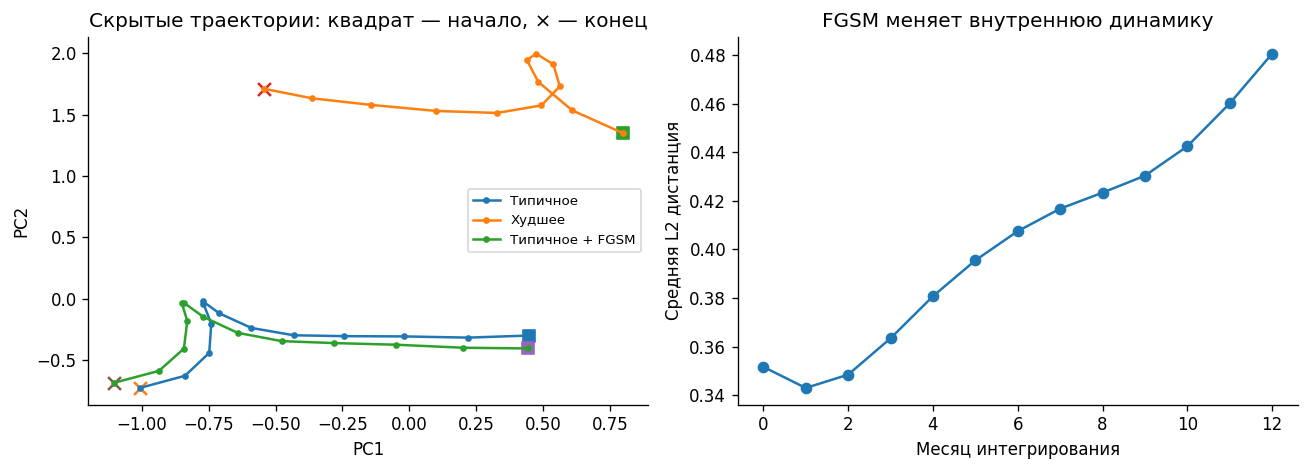

In [6]:
with torch.no_grad():
    _,train_h=model(xt,pt,trajectory=True)
    _,clean_h=model(x,phase,trajectory=True)
    _,adv_h=model(x_adv,phase,trajectory=True)
pca=PCA(n_components=2).fit(train_h.numpy().reshape(-1,12))
print('Объяснённая дисперсия PCA:',pca.explained_variance_ratio_, 'сумма',pca.explained_variance_ratio_.sum())
fig,axes=plt.subplots(1,2,figsize=(11,4))
for label,h in [('Типичное',clean_h[good]),('Худшее',clean_h[bad]),('Типичное + FGSM',adv_h[good])]:
    coords=pca.transform(h.numpy())
    axes[0].plot(coords[:,0],coords[:,1],marker='.',label=label)
    axes[0].scatter(*coords[0],marker='s',s=50)
    axes[0].scatter(*coords[-1],marker='x',s=60)
axes[0].set(xlabel='PC1',ylabel='PC2',title='Скрытые траектории: квадрат — начало, × — конец')
axes[0].legend(fontsize=8)
hidden_distance=torch.linalg.vector_norm(adv_h-clean_h,dim=2).numpy()
axes[1].plot(np.arange(13),hidden_distance.mean(axis=0),marker='o')
axes[1].set(xlabel='Месяц интегрирования',ylabel='Средняя L2 дистанция',title='FGSM меняет внутреннюю динамику')
savefig('06_hidden')

## Интерпретация 2 — чувствительность прогноза к истории
Для каждого из трёх объектов вычисляем
$S_j=\frac1{12}\sum_k|\partial\hat z_k/\partial x_j|$.
Это локальная чувствительность к небольшому изменению конкретного месяца,
а не причинная важность. Используем одинаковый масштаб оси для чистого
и атакованного входа. Для регрессии «типичное» означает медианную ошибку;
модель не выдаёт вероятностную уверенность.

Наиболее чувствительные лаги типичного окна: [0, -1, -12, -13, -17]


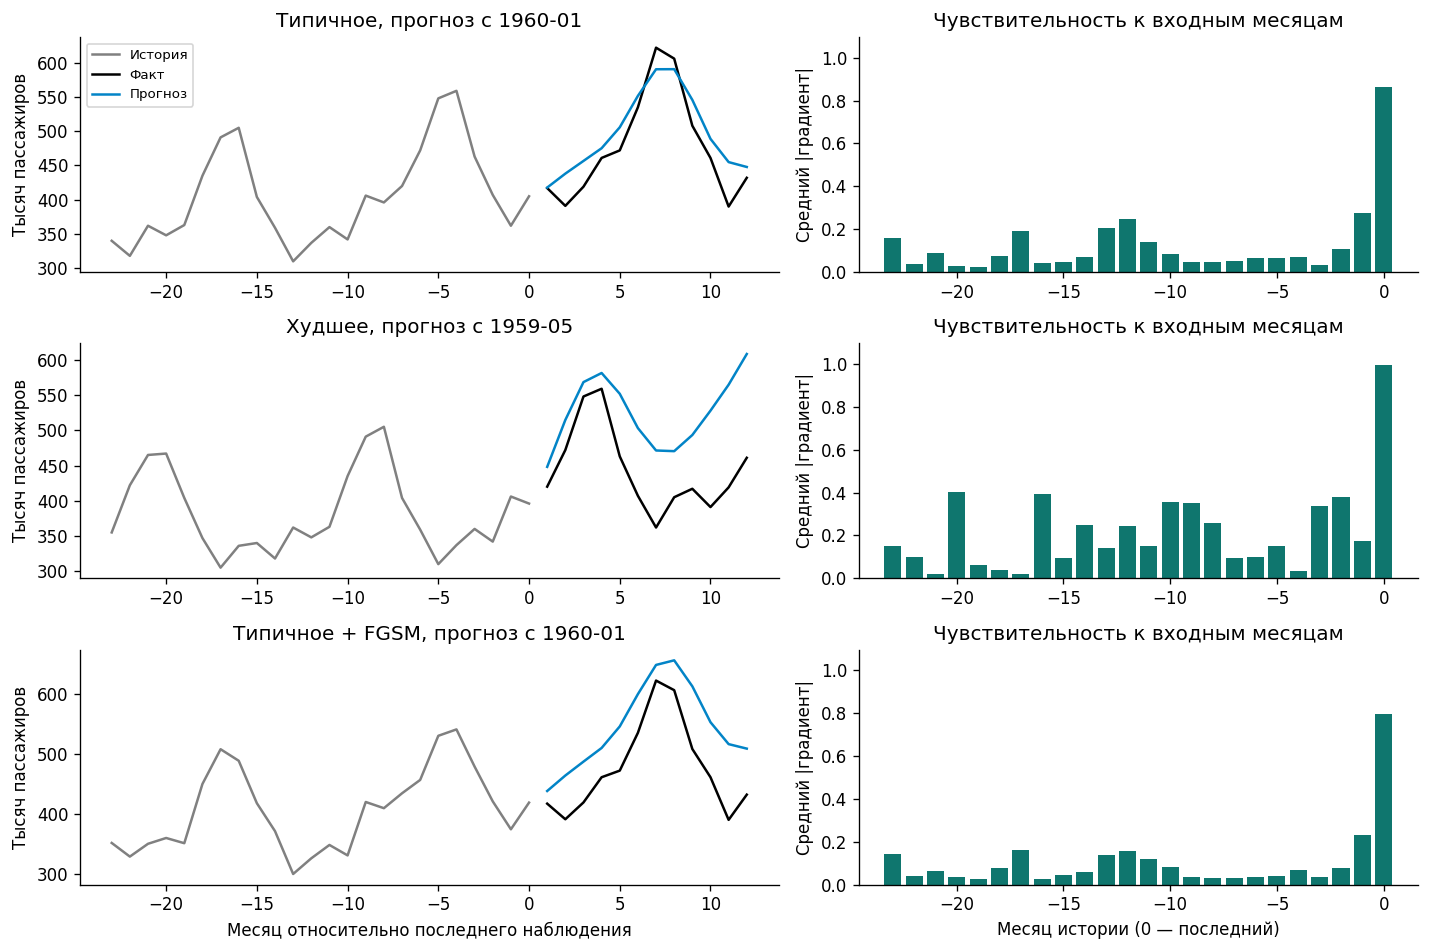

In [7]:
cases=[('Типичное',x[good:good+1],phase[good:good+1],good),
       ('Худшее',x[bad:bad+1],phase[bad:bad+1],bad),
       ('Типичное + FGSM',x_adv[good:good+1],phase[good:good+1],good)]
sal=[]
for label,xx,pp,i in cases:
    xx=xx.detach().requires_grad_(True)
    jac=torch.autograd.functional.jacobian(lambda a:model(a,pp),xx)
    sal.append(jac[0,:,0,:].abs().mean(dim=0).numpy())
sal=np.stack(sal)
fig,axes=plt.subplots(3,2,figsize=(12,8),gridspec_kw={'width_ratios':[1.25,1]})
for row,(label,xx,pp,i) in enumerate(cases):
    o=origins[i]
    axes[row,0].plot(np.arange(-23,1),inverse(xx)[0],color='gray',label='История')
    axes[row,0].plot(np.arange(1,13),truth[i],color='black',label='Факт')
    axes[row,0].plot(np.arange(1,13),predict(xx,pp)[0],color='#0284c7',label='Прогноз')
    axes[row,0].set(title=f'{label}, прогноз с {dates[o]:%Y-%m}',ylabel='Тысяч пассажиров')
    axes[row,1].bar(np.arange(-23,1),sal[row],color='#0f766e')
    axes[row,1].set(ylim=(0,float(sal.max()*1.1)),ylabel='Средний |градиент|',title='Чувствительность к входным месяцам')
axes[0,0].legend(fontsize=8)
axes[-1,0].set_xlabel('Месяц относительно последнего наблюдения')
axes[-1,1].set_xlabel('Месяц истории (0 — последний)')
savefig('07_interpretation')
print('Наиболее чувствительные лаги типичного окна:', (np.argsort(sal[0])[-5:][::-1]-23).tolist())

## Проверка численного решения и роли динамики
Уменьшаем шаг RK4 вдвое при неизменных весах. Малое изменение прогноза означает
согласованность двух дискретизаций на проверенных входах; это не доказательство
абсолютной точности. Затем замораживаем $h(t)=h(0)$: модель вырождается в
прогноз последним значением. Это абляция обученной системы, не сравнение с
отдельно обученной моделью без ODE и не доказательство превосходства архитектуры.

In [8]:
finer=predict(x,phase,substeps=2)
frozen=predict(x,phase,freeze=True)
solver_delta=float(np.abs(finer-pred).max())
print('Максимальное изменение при половинном шаге RK4, тыс.:',solver_delta)
print('Замороженная динамика:',metrics(truth,frozen))
assert np.isfinite(pred).all() and np.isfinite(pred_adv).all()
assert np.allclose(frozen,baselines(x)['Последнее значение'],rtol=1e-5)
summary={'dataset':quality,'seed':SEED,'best_epoch':best_epoch,'parameters':sum(p.numel() for p in model.parameters()),
         'metrics':rows,'robustness':robust.fillna(0).to_dict('records'),
         'sigma_log_train':sigma,'solver_max_delta':solver_delta,
         'pca_variance':pca.explained_variance_ratio_.tolist(),
         'typical_origin':str(dates[origins[good]].date()),'worst_origin':str(dates[origins[bad]].date()),
         'typical_mae':float(window_mae[good]),'worst_mae':float(window_mae[bad]),
         'sensitive_lags':(np.argsort(sal[0])[-5:][::-1]-23).tolist(),
         'hidden_distance_start':float(hidden_distance[:,0].mean()),'hidden_distance_end':float(hidden_distance[:,-1].mean())}
(ROOT/'results.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2))
score.to_csv(ROOT/'metrics.csv',index=False)
history.to_csv(ROOT/'history.csv',index=False)
robust.to_csv(ROOT/'robustness.csv',index=False)
torch.save({'state_dict':model.state_dict(),'mu':mu,'sigma':sigma,'seed':SEED},ROOT/'neural_ode_airpassengers.pt')
clean_mae=metrics(truth,pred)['MAE']
adv_mae=metrics(truth,pred_adv)['MAE']
base_mae=metrics(truth,baselines(x)['Сезонный повтор + рост'])['MAE']
conclusion=f'''Neural ODE: test MAE {clean_mae:.2f} тыс.; сезонный прогноз с ростом: {base_mae:.2f} тыс.
FGSM ε=0.10: MAE {adv_mae:.2f} тыс. ({adv_mae/clean_mae:.2f}× от чистого test).
Худшее окно: {dates[origins[bad]]:%Y-%m}, MAE {window_mae[bad]:.2f} тыс.
Изменение прогноза при половинном шаге RK4: не более {solver_delta:.4f} тыс.
Наиболее чувствительные лаги типичного окна: {summary['sensitive_lags']}.
Расстояние чистого и атакованного скрытых состояний: {summary['hidden_distance_start']:.3f} → {summary['hidden_distance_end']:.3f}.'''
print(conclusion)
(ROOT/'conclusion.txt').write_text(conclusion)

Максимальное изменение при половинном шаге RK4, тыс.: 0.02130126953125
Замороженная динамика: {'MAE': 77.8397445678711, 'RMSE': 99.22621154785156, 'MAPE_pct': 16.524171829223633}
Neural ODE: test MAE 34.60 тыс.; сезонный прогноз с ростом: 26.96 тыс.
FGSM ε=0.10: MAE 85.42 тыс. (2.47× от чистого test).
Худшее окно: 1959-05, MAE 81.63 тыс.
Изменение прогноза при половинном шаге RK4: не более 0.0213 тыс.
Наиболее чувствительные лаги типичного окна: [0, -1, -12, -13, -17].
Расстояние чистого и атакованного скрытых состояний: 0.352 → 0.480.


## Углублённая интерпретация 1 — как скрытые состояния формируют прогноз

PCA выше показывает геометрию, но не связывает её с конкретным предсказанием.
У модели линейный readout, поэтому можно **точно** разложить изменение нормализованного log-прогноза:

$$\widehat z_k-z_{last}=\sum_{j=1}^{12}C_{kj},\qquad C_{kj}=w_j[h_j(t_k)-h_j(0)].$$

Положительный вклад увеличивает прогноз относительно опорного последнего наблюдения,
отрицательный уменьшает. На трёх картах ниже показаны все 12 координат для типичного,
худшего и атакованного типичного окна. Масштаб цвета общий. Это вклад в **log-шкале**,
а не число пассажиров; только сумма вместе с опорным уровнем переводится через exp.
Нумерация координат относится к этому обученному экземпляру и не задаёт физические
факторы. Перепараметризация скрытого пространства может изменить отдельные вклады.

Чтобы понять механизм атаки, отдельно раскладываем разницу прогнозов:

$$\underbrace{\log\widehat y_k^{adv}-\log\widehat y_k}_{\text{весь эффект}}
=\underbrace{\sigma(z_{last}^{adv}-z_{last})}_{\text{опорный уровень}}
+\underbrace{\sigma w^\top\{[h_k^{adv}-h_0^{adv}]-[h_k-h_0]\}}_{\text{скрытая динамика}}.$$

Оба слагаемых измеряются в log-единицах; их сумма точна. Изменение прогноза в процентах
равно $100(\exp(\text{весь эффект})-1)$. Это анализ механизма данной модели,
а не причинное объяснение реального пассажиропотока.

Типичное: MAE=28.60 тыс.; координаты с наибольшим средним |вкладом|: [1, 9, 6]
Худшее: MAE=81.63 тыс.; координаты с наибольшим средним |вкладом|: [1, 2, 10]
Типичное + FGSM: MAE=68.61 тыс.; координаты с наибольшим средним |вкладом|: [1, 9, 2]

Точное разложение эффекта атаки:
 horizon  base_log_change  dynamics_log_change  total_log_change  forecast_change_pct
       1           0.0334               0.0141            0.0475               4.8643
       2           0.0334               0.0238            0.0571               5.8811
       3           0.0334               0.0311            0.0644               6.6535
       4           0.0334               0.0369            0.0702               7.2742
       5           0.0334               0.0425            0.0759               7.8850
       6           0.0334               0.0498            0.0831               8.6684
       7           0.0334               0.0597            0.0930               9.7483
       8           0.0334          

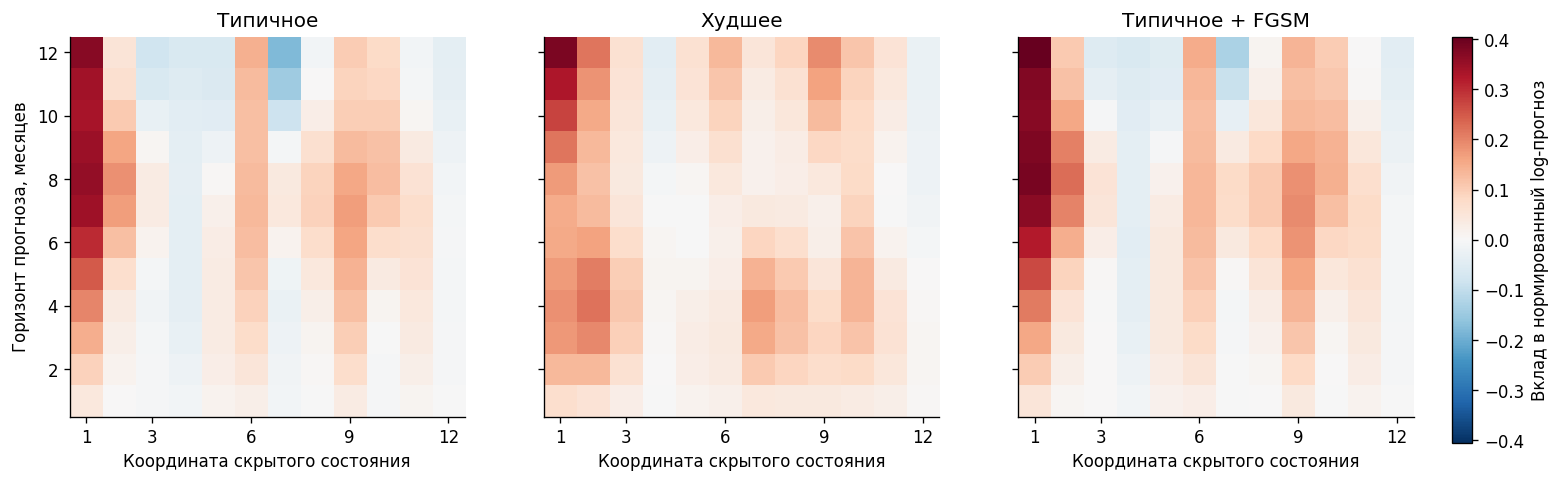

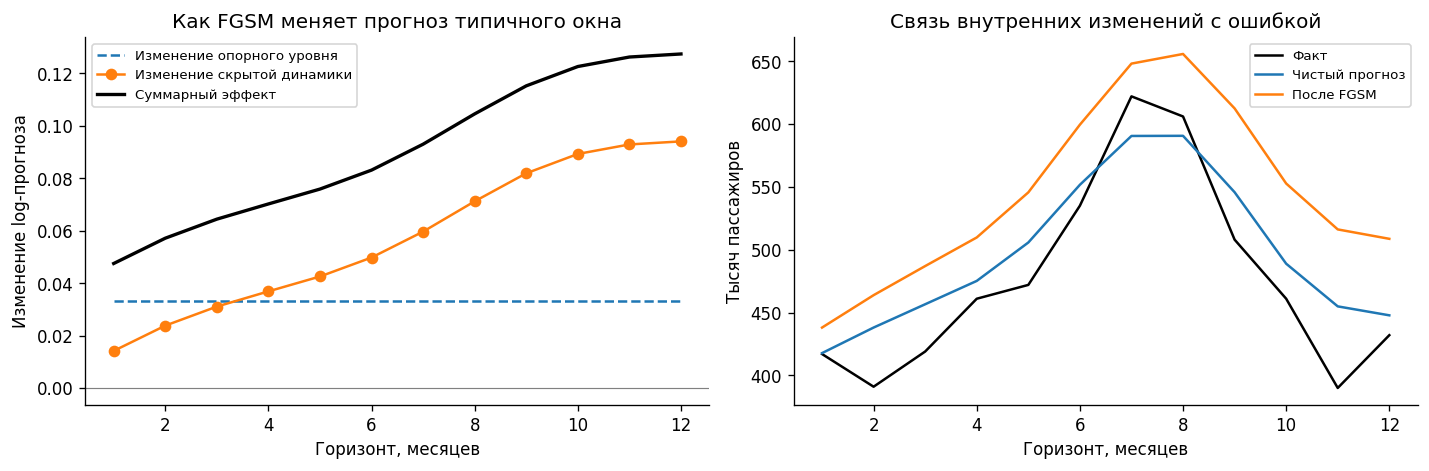

In [9]:

# Повторно используем уже выбранные типичное и худшее окна; веса не меняем.
case_ids = [good, bad, good]
case_names = ['Типичное', 'Худшее', 'Типичное + FGSM']
case_inputs = [x[good:good+1], x[bad:bad+1], x_adv[good:good+1]]
case_phases = [phase[good:good+1], phase[bad:bad+1], phase[good:good+1]]
contributions, case_outputs = [], []
with torch.no_grad():
    for xx, pp in zip(case_inputs, case_phases):
        zz, hh = model(xx, pp, trajectory=True)
        cc = (hh[:,1:,:] - hh[:,:1,:]) * model.readout.weight[0]
        assert torch.allclose(cc.sum(-1) + xx[:,-1:], zz, atol=1e-6)
        contributions.append(cc[0].numpy())
        case_outputs.append(zz[0].numpy())
contributions = np.stack(contributions)
limit = float(np.abs(contributions).max())
fig, axes = plt.subplots(1,3,figsize=(14,4.4),sharey=True)
for i, ax in enumerate(axes):
    im = ax.imshow(contributions[i], origin='lower', aspect='auto', cmap='RdBu_r',
                   vmin=-limit, vmax=limit, extent=[.5,12.5,.5,12.5])
    ax.set(title=case_names[i],xlabel='Координата скрытого состояния',xticks=[1,3,6,9,12])
axes[0].set_ylabel('Горизонт прогноза, месяцев')
fig.colorbar(im, ax=list(axes), fraction=.022, pad=.025, label='Вклад в нормированный log-прогноз')
# Отдельный layout, чтобы общая цветовая шкала не перекрывала панели.
fig.subplots_adjust(left=.06,right=.86,bottom=.16,top=.88,wspace=.20)
fig.savefig(FIG/'08_hidden_contributions.png',dpi=170,bbox_inches='tight')
plt.show()

base_effect = np.full(H, sigma*float(x_adv[good,-1]-x[good,-1]))
dynamic_effect = sigma*(contributions[2]-contributions[0]).sum(axis=1)
total_effect = sigma*(case_outputs[2]-case_outputs[0])
assert np.allclose(base_effect+dynamic_effect,total_effect,atol=2e-6)
fig, axes=plt.subplots(1,2,figsize=(12,4))
k=np.arange(1,H+1)
axes[0].plot(k,base_effect,ls='--',label='Изменение опорного уровня')
axes[0].plot(k,dynamic_effect,marker='o',label='Изменение скрытой динамики')
axes[0].plot(k,total_effect,color='black',lw=2,label='Суммарный эффект')
axes[0].axhline(0,color='gray',lw=.7)
axes[0].set(xlabel='Горизонт, месяцев',ylabel='Изменение log-прогноза',title='Как FGSM меняет прогноз типичного окна')
axes[0].legend(fontsize=8)
axes[1].plot(k,truth[good],color='black',label='Факт')
axes[1].plot(k,pred[good],label='Чистый прогноз')
axes[1].plot(k,pred_adv[good],label='После FGSM')
axes[1].set(xlabel='Горизонт, месяцев',ylabel='Тысяч пассажиров',title='Связь внутренних изменений с ошибкой')
axes[1].legend(fontsize=8)
savefig('09_attack_mechanism')

contribution_rows=[]
for i,name in enumerate(case_names):
    rank=np.argsort(np.abs(contributions[i]).mean(axis=0))[::-1][:3]
    mae=float(np.abs(inverse(case_outputs[i])-truth[case_ids[i]]).mean())
    print(f'{name}: MAE={mae:.2f} тыс.; координаты с наибольшим средним |вкладом|: {(rank+1).tolist()}')
    for horizon in range(H):
        for j in range(12):
            contribution_rows.append({'case':name,'horizon':horizon+1,'coordinate':j+1,'contribution':float(contributions[i,horizon,j])})
pd.DataFrame(contribution_rows).to_csv(ROOT/'hidden_contributions.csv',index=False)
attack_decomposition=pd.DataFrame({'horizon':k,'base_log_change':base_effect,
    'dynamics_log_change':dynamic_effect,'total_log_change':total_effect,
    'forecast_change_pct':100*np.expm1(total_effect)})
attack_decomposition.to_csv(ROOT/'attack_decomposition.csv',index=False)
print('\nТочное разложение эффекта атаки:')
print(attack_decomposition.round(4).to_string(index=False))


## Углублённая интерпретация 2 — какой месяц влияет на какой прогноз

Вместо усреднения по горизонту сохраняем полный якобиан:

$$J_{kj}=\frac{\partial\widehat z_k}{\partial x_j}
=\frac{\partial\log\widehat y_k}{\partial\log y_j}.$$

Здесь $x_j$ — нормализованный логарифм наблюдения. Равенство справа получается
из одинакового масштаба $\sigma$ при преобразовании входа и выхода.
Таким образом, $J_{kj}$ — **локальная эластичность**: рост входного месяца на 1%
даёт приблизительно $J_{kj}$ процентов изменения прогноза на горизонте $k$.
Красный цвет означает увеличение прогноза, синий — уменьшение. Лаг 0 — последний
наблюдённый месяц, −12 — на 12 месяцев раньше него. Это чувствительность
модели, не причинное влияние наблюдения на будущий пассажиропоток.

Проверим объяснение отдельными вмешательствами: увеличим или уменьшим на 1%
последнее наблюдение, лаг −12 и месяц с минимальной средней чувствительностью
в типичном окне. Остальные значения фиксируем. Сравним фактический пересчёт сети
с локальным приближением в исходных единицах:

$$\Delta\widehat y_k\approx\widehat y_k\,J_{kj}\log(1+\delta),\qquad\delta=\pm0.01.$$

Эти одиночные вмешательства отличаются от FGSM, который меняет все месяцы.
Они проверяют локальное объяснение; сильные изменения могут выводить историю
за пределы правдоподобных данных и требуют отдельного исследования.

Оба направления вмешательства; усреднение по 12 горизонтам:
                      mean_forecast_change  mean_absolute_change  linearization_mae
lag input_change_pct                                                               
-19 -1.0                            0.0489                0.1171             0.0025
     1.0                           -0.0435                0.1166             0.0024
-12 -1.0                            1.2471                1.2471             0.0098
     1.0                           -1.2541                1.2541             0.0096
 0  -1.0                           -4.1301                4.1301             0.1038
     1.0                            4.2883                4.2883             0.0966
Максимальная ошибка локального приближения, тыс.: 0.1562294428290638
Доля отрицательных элементов якобиана для трёх объектов: [0.43055556 0.39236111 0.45486111]
{
  "typical_mae_clean": 28.596948623657227,
  "typical_mae_attacked": 68.61402893066406,
  "base_log_chang

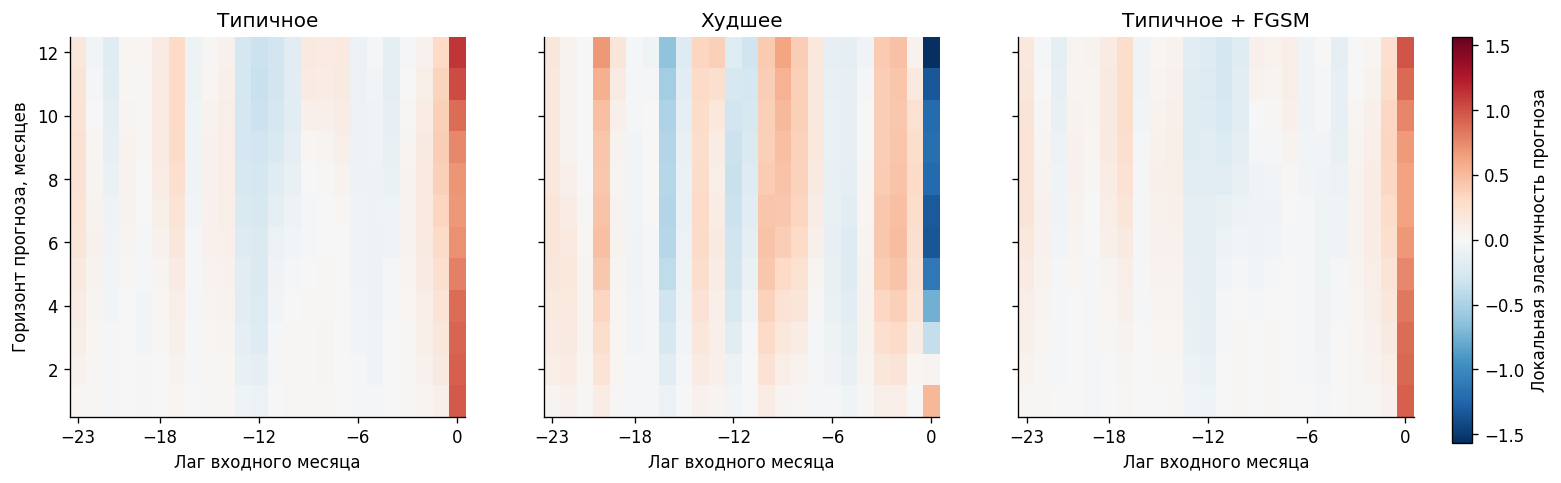

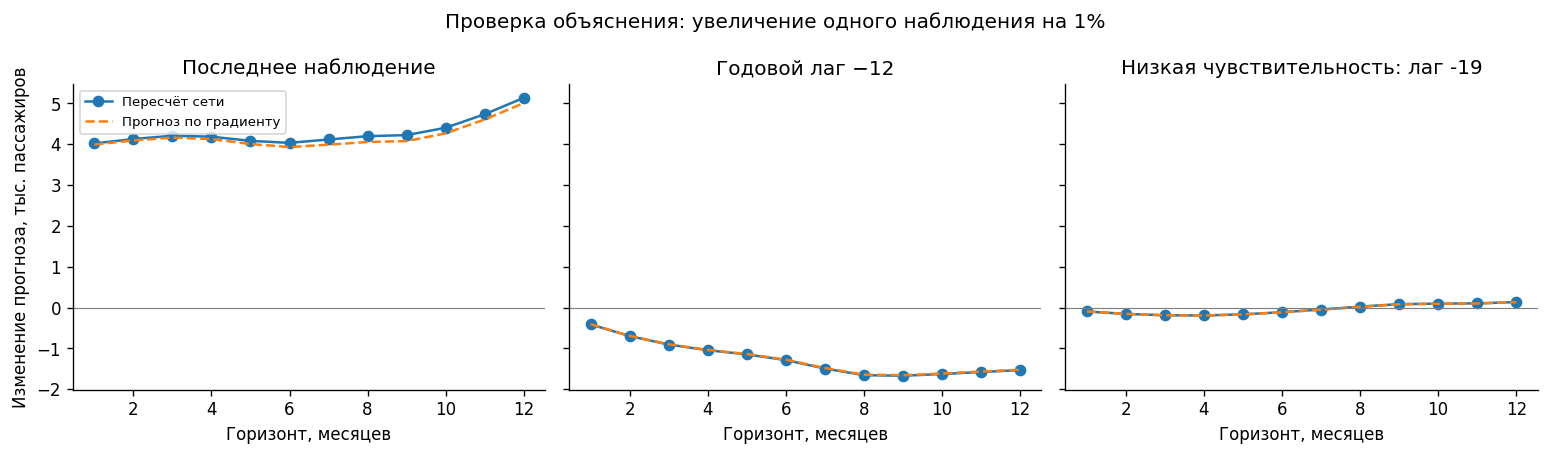

In [10]:

jacobians=[]
for xx, pp in zip(case_inputs,case_phases):
    jac=torch.autograd.functional.jacobian(lambda a:model(a,pp),xx.detach().requires_grad_(True))
    jacobians.append(jac[0,:,0,:].numpy())
jacobians=np.stack(jacobians)
limit=float(np.abs(jacobians).max())
fig,axes=plt.subplots(1,3,figsize=(14,4.4),sharey=True)
for i,ax in enumerate(axes):
    im=ax.imshow(jacobians[i],origin='lower',aspect='auto',cmap='RdBu_r',vmin=-limit,vmax=limit,
                 extent=[-23.5,.5,.5,12.5])
    ax.set(title=case_names[i],xlabel='Лаг входного месяца',xticks=[-23,-18,-12,-6,0])
axes[0].set_ylabel('Горизонт прогноза, месяцев')
fig.colorbar(im,ax=list(axes),fraction=.022,pad=.025,label='Локальная эластичность прогноза')
fig.subplots_adjust(left=.06,right=.86,bottom=.16,top=.88,wspace=.20)
fig.savefig(FIG/'10_signed_jacobian.png',dpi=170,bbox_inches='tight')
plt.show()

low_index=int(np.argmin(np.abs(jacobians[0]).mean(axis=0)))
selected=[('Последнее наблюдение',23),('Годовой лаг −12',11),
          (f'Низкая чувствительность: лаг {low_index-23}',low_index)]
intervention_rows=[]
fig,axes=plt.subplots(1,3,figsize=(13,3.8),sharey=True)
for ax,(label,j) in zip(axes,selected):
    for delta in [-.01,.01]:
        modified=case_inputs[0].clone()
        modified[0,j]+=float(np.log1p(delta)/sigma)
        actual=predict(modified,case_phases[0])[0]-pred[good]
        approximation=pred[good]*jacobians[0,:,j]*np.log1p(delta)
        for kk in range(H):
            intervention_rows.append({'lag':j-23,'input_change_pct':delta*100,'horizon':kk+1,
                'actual_change_thousands':float(actual[kk]),'linear_change_thousands':float(approximation[kk]),
                'absolute_approximation_error':float(abs(actual[kk]-approximation[kk]))})
        if delta>0:
            ax.plot(k,actual,marker='o',label='Пересчёт сети')
            ax.plot(k,approximation,ls='--',label='Прогноз по градиенту')
    ax.axhline(0,color='gray',lw=.7)
    ax.set(title=label,xlabel='Горизонт, месяцев')
axes[0].set_ylabel('Изменение прогноза, тыс. пассажиров')
axes[0].legend(fontsize=8)
fig.suptitle('Проверка объяснения: увеличение одного наблюдения на 1%')
savefig('11_intervention_check')
interventions=pd.DataFrame(intervention_rows)
interventions.to_csv(ROOT/'interventions.csv',index=False)
print('Оба направления вмешательства; усреднение по 12 горизонтам:')
print(interventions.groupby(['lag','input_change_pct']).agg(
    mean_forecast_change=('actual_change_thousands','mean'),
    mean_absolute_change=('actual_change_thousands',lambda a:np.abs(a).mean()),
    linearization_mae=('absolute_approximation_error','mean')).round(4).to_string())
print('Максимальная ошибка локального приближения, тыс.:',interventions.absolute_approximation_error.max())
print('Доля отрицательных элементов якобиана для трёх объектов:',(jacobians<0).mean(axis=(1,2)))

# Машиночитаемые числа для итогового разбора, без переобучения и подбора по test.
interpretation_summary={
    'typical_mae_clean':float(np.abs(pred[good]-truth[good]).mean()),
    'typical_mae_attacked':float(np.abs(pred_adv[good]-truth[good]).mean()),
    'base_log_change':float(base_effect[0]),
    'dynamics_log_change_last':float(dynamic_effect[-1]),
    'total_log_change_last':float(total_effect[-1]),
    'forecast_change_last_pct':float(100*np.expm1(total_effect[-1])),
    'low_sensitivity_lag':low_index-23,
    'max_linearization_error_thousands':float(interventions.absolute_approximation_error.max()),
    'interventions_plus_one':interventions[interventions.input_change_pct>0].groupby('lag').agg(
        mean_change=('actual_change_thousands','mean'),mean_absolute_change=('actual_change_thousands',lambda a:np.abs(a).mean()),
        linearization_mae=('absolute_approximation_error','mean')).reset_index().to_dict('records')}
(ROOT/'interpretation_summary.json').write_text(json.dumps(interpretation_summary,ensure_ascii=False,indent=2))
print(json.dumps(interpretation_summary,ensure_ascii=False,indent=2))

# Проверка последнего наблюдения также для худшего и атакованного объектов.
cross_case=[]
for i,(xx,pp) in enumerate(zip(case_inputs,case_phases)):
    original=predict(xx,pp)[0]
    modified=xx.clone()
    modified[0,-1]+=float(np.log1p(.01)/sigma)
    actual=predict(modified,pp)[0]-original
    approximate=original*jacobians[i,:,-1]*np.log1p(.01)
    cross_case.append({'case':case_names[i],
        'last_observation_elasticity_h1':float(jacobians[i,0,-1]),
        'last_observation_elasticity_h12':float(jacobians[i,-1,-1]),
        'forecast_change_h1_thousands':float(actual[0]),
        'forecast_change_h12_thousands':float(actual[-1]),
        'linearization_mae':float(np.abs(actual-approximate).mean())})
print('Изменение последнего наблюдения на +1% для всех трёх случаев:')
print(pd.DataFrame(cross_case).round(4).to_string(index=False))
pd.DataFrame(cross_case).to_csv(ROOT/'cross_case_interventions.csv',index=False)
pd.DataFrame([{'case':case_names[i],'horizon':k+1,'lag':j-23,'elasticity':float(jacobians[i,k,j])}
    for i in range(3) for k in range(H) for j in range(L)]).to_csv(ROOT/'signed_jacobian.csv',index=False)
interpretation_summary['cross_case']=cross_case
(ROOT/'interpretation_summary.json').write_text(json.dumps(interpretation_summary,ensure_ascii=False,indent=2))


## Результаты углублённой интерпретации

### Скрытые представления и механизм атаки

В типичном окне координаты 1, 9 и 6 дают наибольшие средние абсолютные вклады.
В худшем окне это 1, 2 и 10. Это номера координат данного экземпляра модели,
а не установленные факторы «тренд» или «сезонность». Например, на 12-м горизонте
в типичном окне координата 7 даёт отрицательный вклад −0,1801, частично
компенсируя положительные вклады. В худшем окне её вклад +0,0494.
Истории и календарные фазы этих окон различаются: такое сравнение описывает
разные решения, но само по себе не устанавливает причину ошибки.

Чистое и атакованное типичное окна имеют одну календарную фазу и одну цель,
поэтому их сравнение позволяет проследить эффект конкретного вмешательства.
После FGSM на 12-м горизонте отрицательный вклад координаты 7 ослабевает
с −0,1801 до −0,1267, а положительный вклад координаты 2 растёт с 0,0508 до 0,1059.
Изменения этих двух координат дают наибольшие средние положительные добавки
к прогнозу по горизонту. Остальные координаты тоже участвуют; полные значения
сохранены в hidden_contributions.csv.

На 12-м горизонте общий log-сдвиг равен **0.1274**:
**0.0334** приходится на прямое изменение опорного уровня,
**0.0941** — на изменение скрытой динамики.
В этой точной декомпозиции динамическая часть составляет **73.8% log-сдвига**.
Это не доля процентов изменения пассажиропотока: после exp суммарный прогноз
вырастает на **13.59%**.
MAE типичного окна меняется с **28.60** до
**68.61 тыс.**; эти числа относятся к одному окну,
а не к среднему по всему test (34,60 → 85,42 тыс.).

### Входные признаки и проверка объяснения

При увеличении последнего наблюдения типичного окна на 1% прогноз растёт
в среднем на **4,29 тыс.** Рост наблюдения с лагом −12 на 1% уменьшает прогноз
в среднем на **1,25 тыс.** Поэтому утверждение «годовая история важна» надо
дополнить направлением её влияния. Для выбранного слабого лага −19 среднее
абсолютное изменение составляет лишь **0,117 тыс.**

Для типичного окна при проверке трёх лагов в обоих направлениях (±1%)
максимальная ошибка градиентного приближения составляет **0.156 тыс.**
Это подтверждает локальное объяснение на проверенных вмешательствах, но не
гарантирует его точность при больших изменениях.

Особенно показательно худшее окно. Производная дальнего прогноза по последнему
наблюдению отрицательна: эластичность на 12-м горизонте **−1,568**.
Реальная прибавка 1% к этому наблюдению повышает прогноз первого месяца на
**2,24 тыс.**, но понижает прогноз двенадцатого на **10,26 тыс.**
Средняя ошибка локального приближения здесь 0,475 тыс. Такой разворот знака
не виден на старой диаграмме усреднённых модулей градиента. Это обнаруженное
поведение модели, а не доказательство, что именно оно вызвало исходную ошибку.

Для атакованного типичного окна положительная реакция последнего наблюдения
сохраняется: дополнительное +1% меняет дальний прогноз на **+5,01 тыс.**
Следовательно, повышение прогнозов после FGSM не обязательно сопровождается
ростом локальных градиентов: изменяется само состояние, из которого строится прогноз.

### Соответствие требованию лабораторной

**Метод 1** анализирует скрытые представления: траектории, PCA и точные вклады
координат в выход. **Метод 2** анализирует зависимость решения от входа:
полный знаковый якобиан с проверкой одиночными вмешательствами.
Оба метода применены к типичному, ошибочному и атакованному объектам.
Это два разных уровня объяснения, а не два варианта одной визуализации.


## Итоговые выводы и ограничения

Neural ODE обучена прогнозировать 12 месяцев AirPassengers по истории из 24 месяцев.
Единое нейронное векторное поле описывает скрытую динамику; RK4 интегрирует её,
линейное чтение формирует прогноз в каждом месяце. Годовая фаза задана явно.

Test MAE — 34,60 тыс., у сезонного baseline с ростом — 26,96 тыс. На маленьком
ряду архитектура не получила преимущества над сильным простым прогнозом.
FGSM ε=0,10 повышает среднюю test MAE до 85,42 тыс. (2,47×).

Углублённый анализ связывает изменение входа с конкретными изменениями
скрытых вкладов и выхода. Для типичного окна основная часть дальнего log-сдвига
при атаке проходит через скрытую динамику. Знаковый якобиан обнаруживает
противоположное влияние последнего наблюдения на ближний и дальний прогноз
худшего окна; вмешательство подтверждает этот эффект.

Ограничения: один seed, один короткий ряд, зависимые окна, локальность градиентного
анализа и зависимость скрытых вкладов от выбора координат. FGSM использует цель
как white-box стресс-тест и не измеряет вероятность реальной атаки. Интерпретация
объясняет вычисления модели, а не причинные закономерности пассажиропотока.

Практические направления: проверка обучения с искажениями истории, контроль
измерений, несколько seed и временных разбиений, сравнение с ETS/SARIMA и
более крупные наборы. Результативность этих мер здесь не проверена.
